In [2]:
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_raw_dataset
from utils.face_recognition import load_insightface_model
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
import torch 
from tqdm import tqdm

In [3]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
DATASET_DIR = DATA_DIR / "test_geneset_embeddings"

GENESET = "easy"

In [4]:
# celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
# easy_geneset = ProcessedDataset(DATA_DIR / "easy_geneset_embeddings")

# IP-adapter

In [5]:
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

ck_image = cv2.imread("../../data/ck_faces_dataset/brad_pit/brad_pit.png")
real_image = cv2.imread("../../data/real_faces_dataset/brad_pit/006_aee8d88b.jpg")

def get_embed(app, image):
    faces = app.get(image)
    faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
    landmarks = faces[0].kps
    aligned = face_align.norm_crop(image, landmark=landmarks, image_size=224)
    return faceid_embeds, aligned

ck_embed, ck_aligned = get_embed(app, ck_image)
real_embed, real_aligned = get_embed(app, real_image)

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


In [6]:
# cosine similarity 
cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cos(ck_embed, real_embed)

tensor([0.1222])

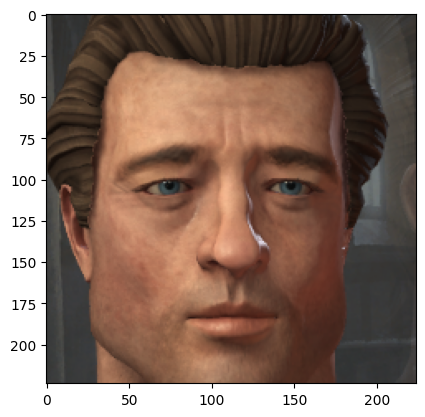

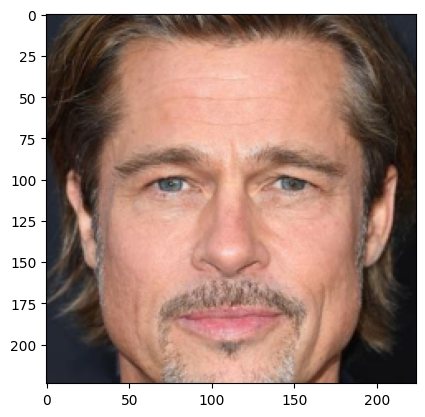

In [7]:
plt.imshow(cv2.cvtColor(ck_aligned, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv2.cvtColor(real_aligned, cv2.COLOR_BGR2RGB))
plt.show()

## generate image

In [8]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image
from huggingface_hub import hf_hub_download

from thirdparty.ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus

v2 = False
base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
image_encoder_path = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"
repo_id = "h94/IP-Adapter-FaceID"
ip_ckpt = "ip-adapter-faceid-plus_sd15.bin" if not v2 else "ip-adapter-faceid-plusv2_sd15.bin"
device = "cpu"
ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float32,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)

# load ip-adapter
ip_model = IPAdapterFaceIDPlus(pipe, image_encoder_path, ckpt_path, device, torch_dtype=torch.float32)

# generate image
prompt = None
negative_prompt = "monochrome, lowres, bad anatomy, worst quality, low quality, blurry"

images = ip_model.generate(
     prompt=prompt, negative_prompt=negative_prompt, face_image=ck_aligned, faceid_embeds=real_embed, shortcut=v2, s_scale=1.0,
     num_samples=4, width=512, height=768, num_inference_steps=30, seed=2023
)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 5/5 [00:07<00:00,  1.47s/it]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer"

In [ ]:
images

[<PIL.Image.Image image mode=RGB size=512x768>,
 <PIL.Image.Image image mode=RGB size=512x768>,
 <PIL.Image.Image image mode=RGB size=512x768>,
 <PIL.Image.Image image mode=RGB size=512x768>]

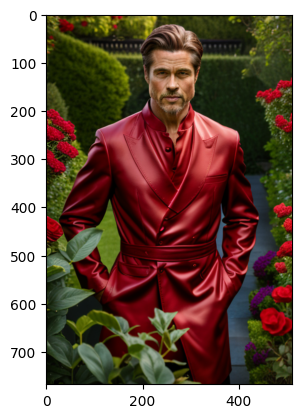

In [ ]:
plt.imshow(images[1])